In [1]:
model_name = "vit-ragdoll"


import iree
import iree.compiler
import iree.runtime
import torch
import numpy as np
from torch import nn
from torchvision import models

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from ragdoll.compiler import *
from ragdoll.benchmark import *
import ragdoll

def get_dataframe(vjp, item):
    return pd.concat([
        pd.DataFrame({
            "time": vjp,
            "pass": "VJP",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=1):
    return ti(stmt, globals=globals(), number=n) * 1000 / n



BENCHMARK_REPEAT=33
df = pd.DataFrame()

def load_executable(fb_file):
    config = iree.runtime.system_api.Config("cuda")
    vmi = iree.runtime.VmInstance()
    # replace compile with args of fatbin type
    # fb_file = ragdoll.compile(mlir, "gpu", "input", "codegen", benchmark=True)
    with open(fb_file, 'rb') as f:
        binary_data = f.read()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
    vmo = iree.runtime.load_vm_module(vmm, config)
    return vmo

In [2]:
import gc
model_file_base = "vit.mlir"
strategy = "heuristic"
for bs in range(1, 36):
    model_file = model_file_base + ".bs{}".format(bs)
    source_file = model_file + ".{}".format(strategy)
    target_file = source_file + ".vmfb"
    #"""
    # gen model with specified batch-size
    !ragdoll-opt {model_file_base} --ragdoll-autodiff-prepare-batch-size=batchsize={bs} > {model_file}
    
    !ragdoll-opt {model_file}  \
    --canonicalize \
    --enable-cse-in-legalizer \
    --symbol-dce \
    --ragdoll-autodiff-vjp-public-functions='strategy=heuristic' \
    --ragdoll-autodiff-vjp \
    --inline \
    --ragdoll-autodiff-inline-function-call \
    --ragdoll-initialisation \
    --eliminate-empty-tensors \
    --ragdoll-legalise-to-iree-compatibility \
    --ragdoll-raise-linalg-to-tosa \
    --ragdoll-forward-func-removal \
    --canonicalize \
    --cse > {source_file}
    
    !iree-compile {source_file} \
    -o {target_file} \
    --iree-hal-target-backends=cuda \
    --iree-hal-benchmark-dispatch-repeat-count={BENCHMARK_REPEAT} \
    --iree-hal-cuda-llvm-target-arch=sm_70
    #"""
    
    #ragdoll_binary = load_executable(target_file)

    image = torch.randn(bs, 3, 224, 224)
    image_np = image.detach().cpu().numpy()
    image_t = torch.randn(bs, 224, 224, 3)
    image_np_t = image_t.detach().cpu().numpy()
    model = models.vit_b_16().train(False)
    model.load_state_dict({k: torch.ones_like(v) * 0.23421 for k, v in model.state_dict().items()})
    output = model(image)
    grad = torch.randn_like(output)
    grad_np = grad.cpu().numpy()

    try:
        #f1 = timeit("ragdoll_binary.forward(image_np_t)") / BENCHMARK_REPEAT
        #print('ragdoll-opt1-gpu-forward in timeit: ', f1)
        #"""
        b1 = ragdoll_model_benchmark(
            target_file,
            "dforward",
            [(bs, 1000)],
            device='gpu',
            warmups=3,
            repetitions=BENCHMARK_REPEAT, 
            measure_count=4)
        b1 = np.mean(b1)
        #"""
        #b1 = timeit("ragdoll_binary.dforward(grad_np)") / BENCHMARK_REPEAT
        #print('ragdoll-opt1-gpu-forward in timeit: ', b1)
        df = pd.concat([df, get_dataframe(b1, "Ragdoll-Autodiff at batch-size = {}".format(bs))])
        #df = pd.concat([df, get_dataframe(f1, b1, "Ragdoll-Autodiff at batch-size = {}".format(bs))])
    except Exception as e:
        print(f"处理模型时出错，批量大小 {bs}: {e}")
    print(df)

(1, 1000)
['1x1000xf32']
     time pass                                item
0  14.175  VJP  Ragdoll-Autodiff at batch-size = 1
(2, 1000)
['2x1000xf32']
     time pass                                item
0  14.175  VJP  Ragdoll-Autodiff at batch-size = 1
0  25.275  VJP  Ragdoll-Autodiff at batch-size = 2
(3, 1000)
['3x1000xf32']
     time pass                                item
0  14.175  VJP  Ragdoll-Autodiff at batch-size = 1
0  25.275  VJP  Ragdoll-Autodiff at batch-size = 2
0  37.650  VJP  Ragdoll-Autodiff at batch-size = 3
(4, 1000)
['4x1000xf32']
     time pass                                item
0  14.175  VJP  Ragdoll-Autodiff at batch-size = 1
0  25.275  VJP  Ragdoll-Autodiff at batch-size = 2
0  37.650  VJP  Ragdoll-Autodiff at batch-size = 3
0  49.450  VJP  Ragdoll-Autodiff at batch-size = 4
(5, 1000)
['5x1000xf32']
     time pass                                item
0  14.175  VJP  Ragdoll-Autodiff at batch-size = 1
0  25.275  VJP  Ragdoll-Autodiff at batch-size = 2
0  37.65

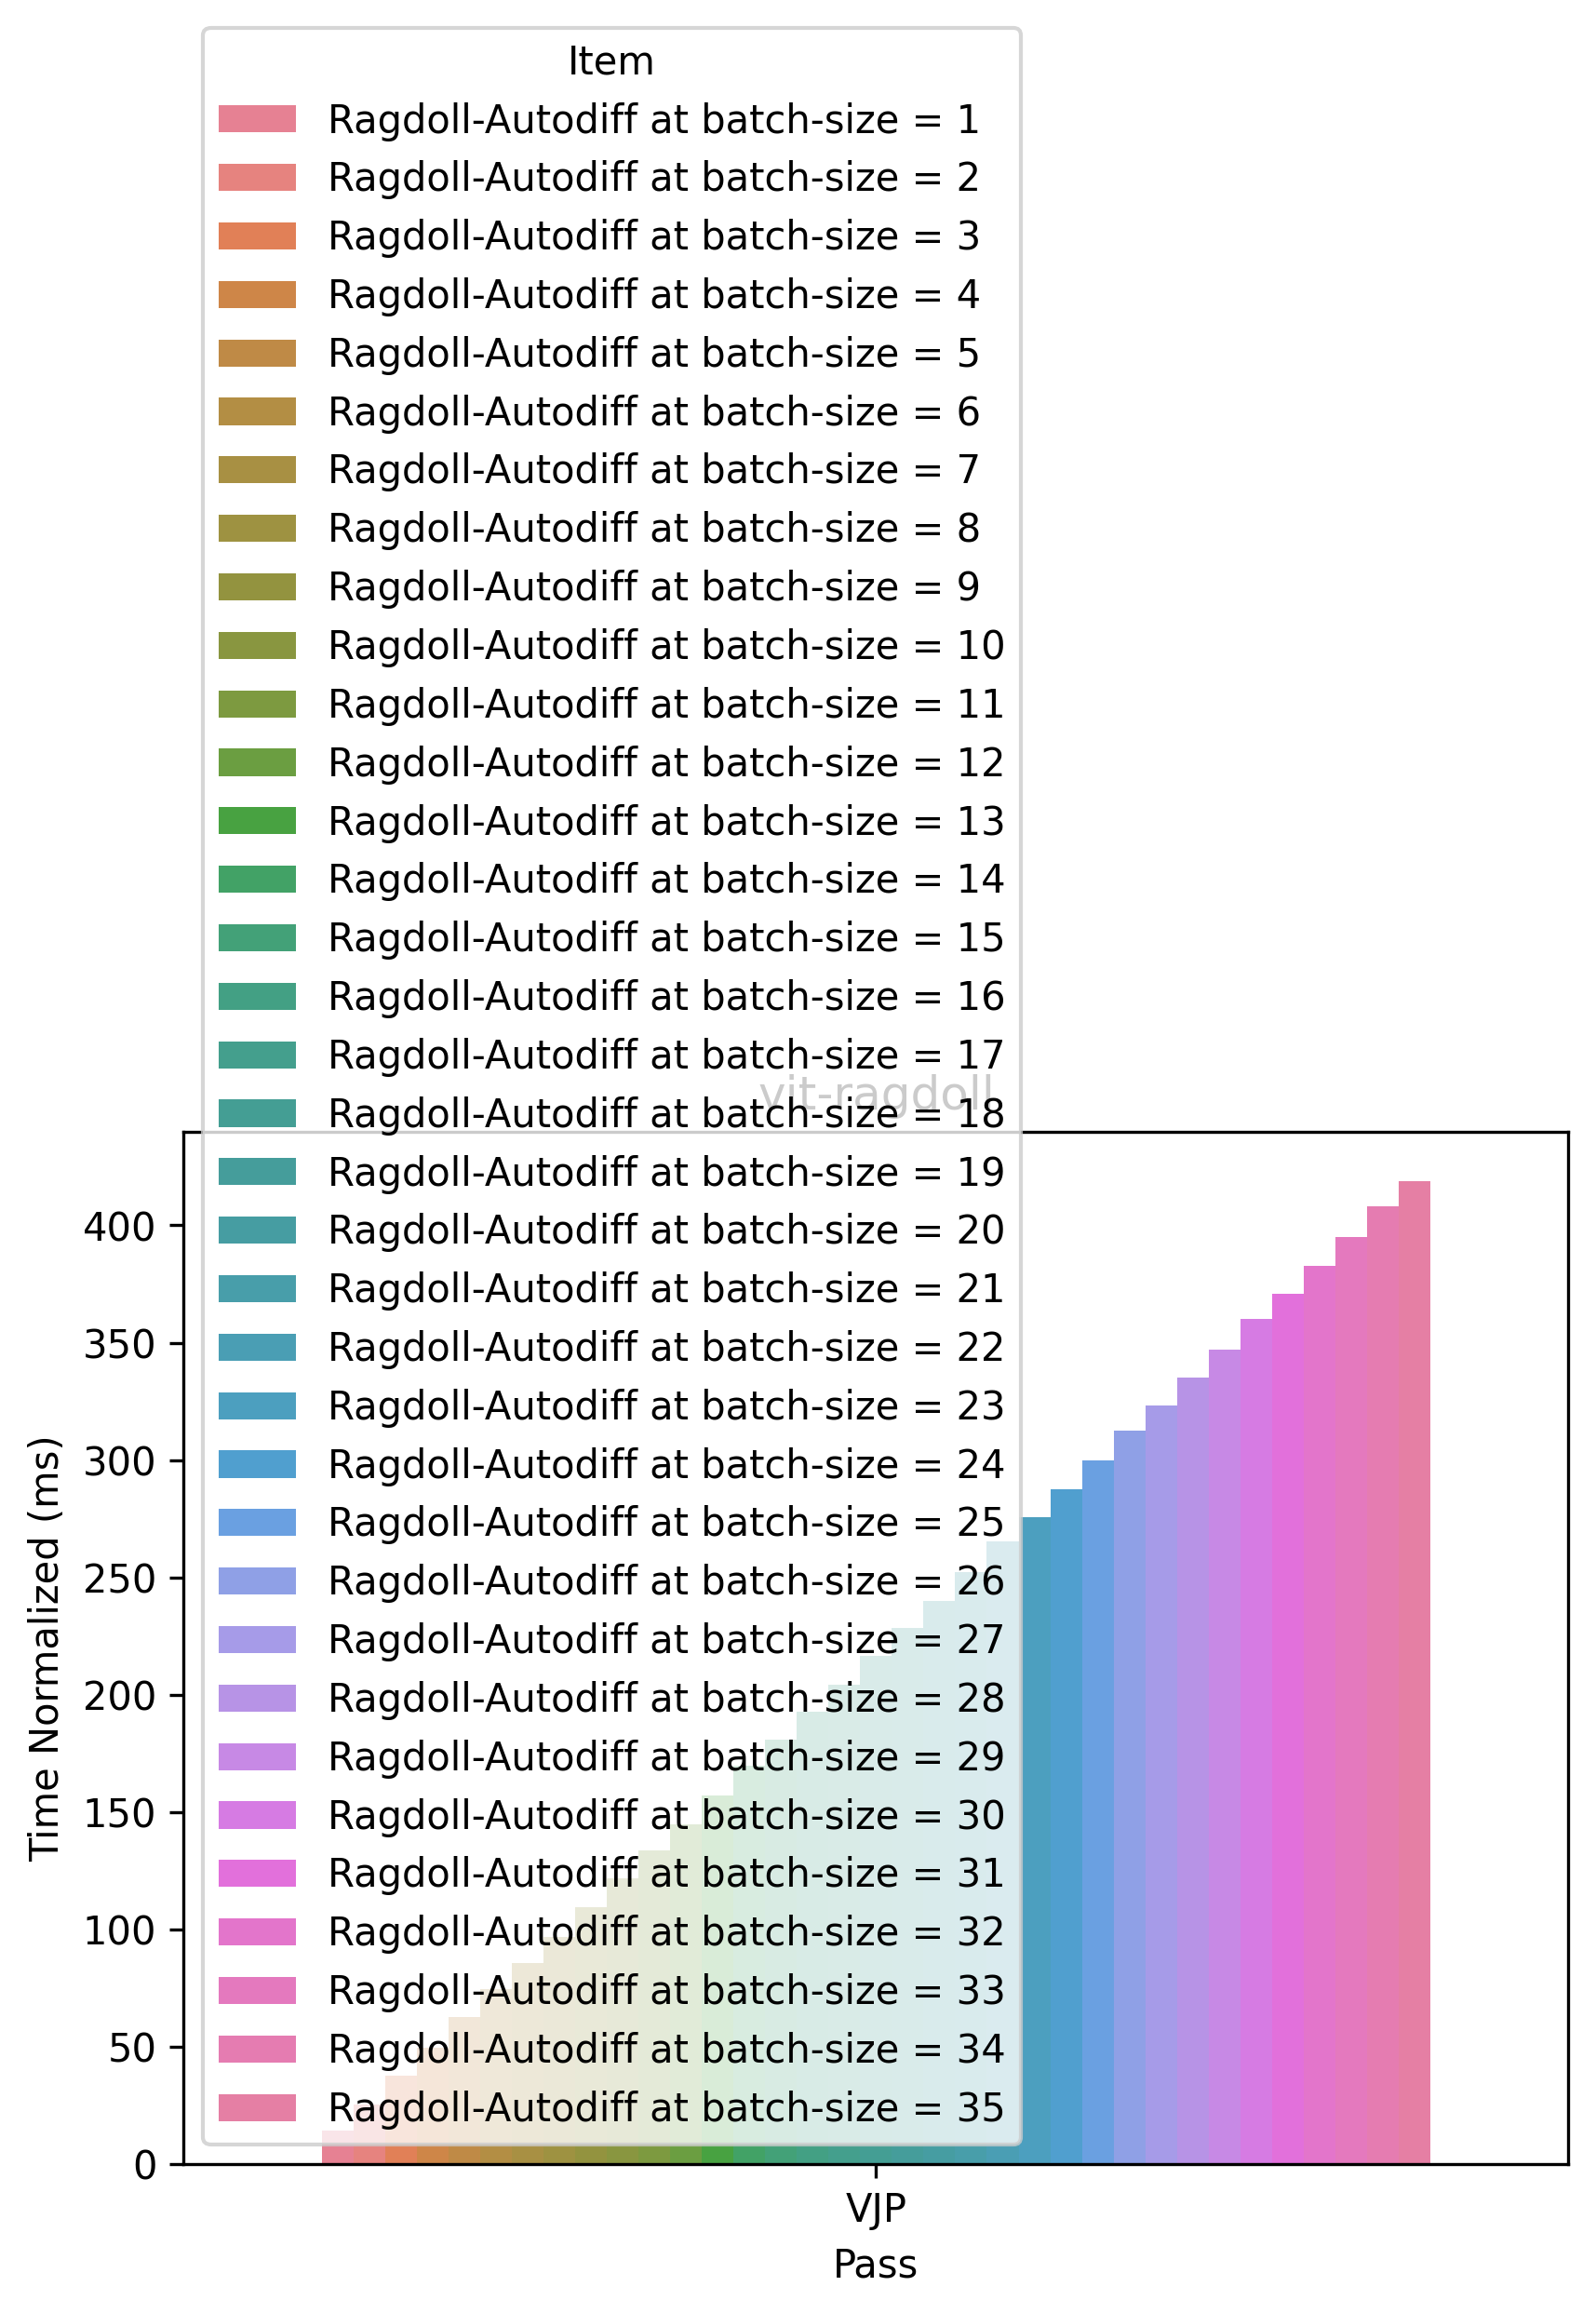

In [3]:
df.style.hide(axis="index")
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time Normalized (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")

In [6]:
df.to_csv('output.csv')
df.transpose().to_csv('output2.csv')